You can find the data dictionary at this link:

https://data.cms.gov/sites/default/files/2025-12/Medicare%20Monthly%20Enrollment%20Data%20Dictionary.pdf

Just like the data, it is publically available on the CMS website.

First, I'll import my core libraries as well as the dataset, followed by a quick overview.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import warnings
warnings.filterwarnings("ignore")

In [3]:
file = '/content/drive/MyDrive/Datasets/enrollment_data.csv'
df = pd.read_csv(file)
df.head()

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
0,2013,Year,National,US,National,Total,,52425659,37613096,14812563,...,47959444,33147099,14812345,35679758,22661451,13018307,10000861,1030113.0,409204.0,24239580
1,2013,Year,State,AL,Alabama,Total,01,921477.0,711448.0,210029.0,...,862992.0,652965.0,210026.0,637247.0,437749.0,199498.0,205496.0,32790.0,11452.0,387510.0
2,2013,Year,County,AL,Alabama,Autauga County,01001,9323.0,6484.0,2840.0,...,8742.0,5902.0,2840.0,6036.0,3268.0,2767.0,1839.0,296.0,105.0,3796.0
3,2013,Year,County,AL,Alabama,Baldwin County,01003,41033.0,28775.0,12258.0,...,38651.0,26393.0,12258.0,27352.0,15593.0,11759.0,5276.0,867.0,379.0,20830.0
4,2013,Year,County,AL,Alabama,Barbour County,01005,5847.0,5036.0,810.0,...,5515.0,4704.0,810.0,4170.0,3410.0,759.0,1783.0,304.0,73.0,2009.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553747 entries, 0 to 553746
Data columns (total 60 columns):
 #   Column                                        Non-Null Count   Dtype 
---  ------                                        --------------   ----- 
 0   YEAR                                          553747 non-null  int64 
 1   MONTH                                         553747 non-null  object
 2   BENE_GEO_LVL                                  553747 non-null  object
 3   BENE_STATE_ABRVTN                             553747 non-null  object
 4   BENE_STATE_DESC                               553747 non-null  object
 5   BENE_COUNTY_DESC                              553747 non-null  object
 6   BENE_FIPS_CD                                  553747 non-null  object
 7   TOT_BENES                                     553747 non-null  object
 8   ORGNL_MDCR_BENES                              553747 non-null  object
 9   MA_AND_OTH_BENES                              553747 non-nu

In [5]:
df.BENE_FIPS_CD.nunique()

3347

This is a big dataset, which is why I've been assigned to analyze it with a team. I'll first filter out the unessecary years. The company specified that I should only look through data from 2020-2025. Any other years will be removed.

In [6]:
yl = [2020, 2021, 2022, 2023, 2024, 2025]
df1 = df[df['YEAR'].isin(yl)]
df1['YEAR'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

Next, I will only choose data from my assigned states. I was assigned states from the midwest region in the list below.

In [7]:
mids = [
    "North Dakota",
    "South Dakota",
    "Minnesota",
    "Wisconsin",
    "Michigan",
    "Iowa",
    "Illinois",
    "Indiana",
    "Ohio",
    "Nebraska",
    "Missouri",
    "Kansas"
]

df2 = df1[df1['BENE_STATE_DESC'].isin(mids)]
df2['BENE_STATE_DESC'].unique()

array(['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota',
       'Missouri', 'Nebraska', 'North Dakota', 'Ohio', 'South Dakota',
       'Wisconsin'], dtype=object)

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80925 entries, 304121 to 553631
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   YEAR                                          80925 non-null  int64 
 1   MONTH                                         80925 non-null  object
 2   BENE_GEO_LVL                                  80925 non-null  object
 3   BENE_STATE_ABRVTN                             80925 non-null  object
 4   BENE_STATE_DESC                               80925 non-null  object
 5   BENE_COUNTY_DESC                              80925 non-null  object
 6   BENE_FIPS_CD                                  80925 non-null  object
 7   TOT_BENES                                     80925 non-null  object
 8   ORGNL_MDCR_BENES                              80925 non-null  object
 9   MA_AND_OTH_BENES                              80925 non-null  object
 1

Now I have all my assigned data from the master spreadsheet. In the info above you may notice that there are no null values. I checked the original spreadsheet in Excel, and realized that this is because missing values appear to be represented by an asterisk (*) instead of a blank or np.nan. To get a better idea of missing data distributions, I'll change the asterisks to np.nan.

In [9]:
df3 = df2.replace('*', np.nan)
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80925 entries, 304121 to 553631
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   YEAR                                          80925 non-null  int64 
 1   MONTH                                         80925 non-null  object
 2   BENE_GEO_LVL                                  80925 non-null  object
 3   BENE_STATE_ABRVTN                             80925 non-null  object
 4   BENE_STATE_DESC                               80925 non-null  object
 5   BENE_COUNTY_DESC                              80925 non-null  object
 6   BENE_FIPS_CD                                  80925 non-null  object
 7   TOT_BENES                                     80025 non-null  object
 8   ORGNL_MDCR_BENES                              79360 non-null  object
 9   MA_AND_OTH_BENES                              79360 non-null  object
 1

There are varying degrees of missing data distributions, some higher than others. I will be leaving them alone for 2 reasons:

1. This is an exploratory analysis, not machine learning. As long as I factor null values out of my future calculations, the integrity of my results will remain intact.

2. There could be a myriad of reasons for missing data in this dataset, including underreporting, population differences and so on. I noticed that a lot of the columns with missing data are in the demographic columns. This data has lots of duplicate months, years and locations because they are duplicated based on county. Counties can have large fluctuations in demographic distribution, so it's possible that the missing data isn't truly missing, just distributed around the state by it's county column. This means that despite the presence of several missing values, the data can still be considered complete and usable.

Next, I want to check outliers, but we have a bit of a data type issue. Almsot all the columns are classified as 'objects', meaning I can't run calculations on them even if they're numbers. Let's deal with that first. There's 7 columns that should be objects and around 60 that shouldn't, so I'll just put those 7 columns in a list and exclude them from the conversion.

In [10]:
list = ['YEAR', 'MONTH', 'BENE_GEO_LVL', 'BENE_STATE_ABRVTN', 'BENE_STATE_DESC', 'BENE_COUNTY_DESC', 'BENE_FIPS_CD']

for col in df3.columns:
    if col not in list:
        df3[col] = df3[col].astype('float64')

df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80925 entries, 304121 to 553631
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   YEAR                                          80925 non-null  int64  
 1   MONTH                                         80925 non-null  object 
 2   BENE_GEO_LVL                                  80925 non-null  object 
 3   BENE_STATE_ABRVTN                             80925 non-null  object 
 4   BENE_STATE_DESC                               80925 non-null  object 
 5   BENE_COUNTY_DESC                              80925 non-null  object 
 6   BENE_FIPS_CD                                  80925 non-null  object 
 7   TOT_BENES                                     80025 non-null  float64
 8   ORGNL_MDCR_BENES                              79360 non-null  float64
 9   MA_AND_OTH_BENES                              79360 non-null

Before checking outliers, I want to see if the data is doing any calculations on it's own. That could mess up my own calculations later. Let's check the lookup columns first.

In [11]:
lookup = ['YEAR', 'MONTH', 'BENE_GEO_LVL', 'BENE_STATE_ABRVTN', 'BENE_STATE_DESC']

for i in lookup:
  print(f'Here are the unique values of {i}:')
  print(df3[i].unique().tolist())
  print('\n')

Here are the unique values of YEAR:
[2020, 2021, 2022, 2023, 2024, 2025]


Here are the unique values of MONTH:
['Year', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


Here are the unique values of BENE_GEO_LVL:
['State', 'County']


Here are the unique values of BENE_STATE_ABRVTN:
['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH', 'SD', 'WI']


Here are the unique values of BENE_STATE_DESC:
['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'Ohio', 'South Dakota', 'Wisconsin']




Everything here looks kosher, but I noticed a little item marked 'Year' in the MONTH column. Let's check on it.

In [12]:
test = df3[
    (df3['MONTH'] == 'Year') &
    (df3['BENE_COUNTY_DESC'] == 'Adams County') &
    (df3['BENE_STATE_DESC'] == 'Ohio')
    ]

test[['YEAR', 'MONTH','BENE_STATE_ABRVTN', 'BENE_COUNTY_DESC', 'TOT_BENES']].set_index('YEAR')

,MONTH,BENE_STATE_ABRVTN,BENE_COUNTY_DESC,TOT_BENES
YEAR,,,,
2020,Year,OH,Adams County,6520.0
2021,Year,OH,Adams County,6548.0
2022,Year,OH,Adams County,6511.0
2023,Year,OH,Adams County,6731.0
2024,Year,OH,Adams County,7061.0


Okay, so if we specify a single state and county for any record with the entry 'Year' in the MONTH column, we get 5 entries, one per year. This is good, as it means it's not just junk data and serves a purpose, but it's still a bit odd. First I'll use the TOT_BENES column to see if it's a kind of calculation. The parameters will be 2020, Ohio and Adams County.

In [13]:
test2 = df3[
    (df3['BENE_COUNTY_DESC'] == 'Adams County') &
    (df3['BENE_STATE_DESC'] == 'Ohio') &
    (df3['YEAR'] == 2020)
    ]

test2[['YEAR', 'MONTH','BENE_STATE_ABRVTN', 'BENE_COUNTY_DESC', 'TOT_BENES']].set_index('YEAR')

,MONTH,BENE_STATE_ABRVTN,BENE_COUNTY_DESC,TOT_BENES
YEAR,,,,
2020,Year,OH,Adams County,6520.0
2020,January,OH,Adams County,6513.0
2020,February,OH,Adams County,6510.0
2020,March,OH,Adams County,6506.0
2020,April,OH,Adams County,6518.0
2020,May,OH,Adams County,6509.0
2020,June,OH,Adams County,6511.0
2020,July,OH,Adams County,6518.0
2020,August,OH,Adams County,6525.0


Here we have all 12 months of 2020 for this specific county. Everything looks as it should. Let's do a quick .describe and see what's there.

In [14]:
test2['TOT_BENES'].describe()

,TOT_BENES
count,13.000000
mean,6519.615385
std,10.634366
min,6506.000000
25%,6511.000000
50%,6518.000000
75%,6525.000000
max,6537.000000


Alright, this about answers it, 'Year' indicates a mean calculation. In the original test where I checked the 'Year' entries, the TOT_BENES appeared as 6520.0 for the year 2020 in the specified county. Then when I took out the 'Year' entry and specified 2020 for all months, the mean came out to 6519.583333. Rounded up, it matches the original test. Let's test it one more time to confirm.

In [15]:
test = df3[
    (df3['MONTH'] == 'Year') &
     (df3['BENE_COUNTY_DESC'] == 'Cook County') &
      (df3['BENE_STATE_DESC'] == 'Illinois')
      ]

test.head(50)

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
304137,2020,Year,County,IL,Illinois,Cook County,17031,830396.0,560877.0,269519.0,...,740586.0,471089.0,269497.0,632024.0,384108.0,247916.0,197083.0,17068.0,4890.0,412984.0
347505,2021,Year,County,IL,Illinois,Cook County,17031,833441.0,532402.0,301039.0,...,745541.0,444556.0,300985.0,645294.0,363647.0,281646.0,199286.0,16513.0,4110.0,425384.0
390874,2022,Year,County,IL,Illinois,Cook County,17031,841681.0,512164.0,329517.0,...,752324.0,422858.0,329465.0,660139.0,350601.0,309537.0,211913.0,14199.0,3284.0,430742.0
434255,2023,Year,County,IL,Illinois,Cook County,17031,853035.0,497429.0,355606.0,...,761689.0,406484.0,355205.0,675699.0,339301.0,336398.0,222137.0,13217.0,3615.0,436730.0
477636,2024,Year,County,IL,Illinois,Cook County,17031,864789.0,485878.0,378910.0,...,770461.0,392098.0,378363.0,702143.0,342201.0,359942.0,228709.0,13768.0,0.0,459666.0


In Cook County, the mean for ORGNL_MDCR_BENES is 560877.0. Now I'll filter the data and run the same calculation as before.

In [16]:
test2 = df3[
    (df3['BENE_COUNTY_DESC'] == 'Cook County') &
    (df3['BENE_STATE_DESC'] == 'Illinois') &
    (df3['YEAR'] == 2020)
    ]

test2

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
304137,2020,Year,County,IL,Illinois,Cook County,17031,830396.0,560877.0,269519.0,...,740586.0,471089.0,269497.0,632024.0,384108.0,247916.0,197083.0,17068.0,4890.0,412984.0
307473,2020,January,County,IL,Illinois,Cook County,17031,824956.0,560100.0,264856.0,...,735963.0,471165.0,264798.0,629051.0,386232.0,242819.0,191685.0,17684.0,5491.0,414191.0
310809,2020,February,County,IL,Illinois,Cook County,17031,826040.0,561386.0,264654.0,...,736531.0,471895.0,264636.0,629664.0,386940.0,242724.0,193023.0,17601.0,5445.0,413595.0
314145,2020,March,County,IL,Illinois,Cook County,17031,827484.0,561826.0,265658.0,...,737146.0,471506.0,265640.0,630403.0,386602.0,243801.0,194519.0,17551.0,5388.0,412945.0
317481,2020,April,County,IL,Illinois,Cook County,17031,828438.0,561866.0,266572.0,...,737343.0,470789.0,266554.0,631181.0,386367.0,244814.0,195709.0,17356.0,4812.0,413304.0
320817,2020,May,County,IL,Illinois,Cook County,17031,828189.0,561159.0,267030.0,...,736716.0,469704.0,267012.0,630698.0,385302.0,245396.0,195974.0,17177.0,4759.0,412788.0
324153,2020,June,County,IL,Illinois,Cook County,17031,828401.0,561192.0,267209.0,...,736584.0,469393.0,267191.0,630613.0,384941.0,245672.0,196144.0,17081.0,4748.0,412640.0
327489,2020,July,County,IL,Illinois,Cook County,17031,829808.0,561230.0,268578.0,...,740896.0,472336.0,268560.0,631465.0,384392.0,247073.0,197067.0,16969.0,4725.0,412704.0
330825,2020,August,County,IL,Illinois,Cook County,17031,831557.0,560460.0,271097.0,...,742606.0,471527.0,271079.0,632296.0,382676.0,249620.0,198109.0,16869.0,4683.0,412635.0
334161,2020,September,County,IL,Illinois,Cook County,17031,833276.0,560453.0,272823.0,...,744228.0,471423.0,272805.0,633710.0,382332.0,251378.0,199294.0,16752.0,4672.0,412992.0


In [17]:
test2['ORGNL_MDCR_BENES'].describe()

,ORGNL_MDCR_BENES
count,13.000000
mean,560877.000000
std,616.445997
min,560100.000000
25%,560453.000000
50%,560877.000000
75%,561230.000000
max,561866.000000


Even with a different state, county and column, the resulting averages match. This means that I will drop all entries indicating 'Year' in the 'MONTH' column. This could wreck later calculations, and as demonstrated, I can always make this calculation myself later if I need it.

In [18]:
df4 = df3[df3['MONTH'] != 'Year']

Now then, Let's start by checking outliers in the TOT_BENES column. I know there's a lot of columns, but with data like this, checking one or two for oddities can often fix the problems with the rest.

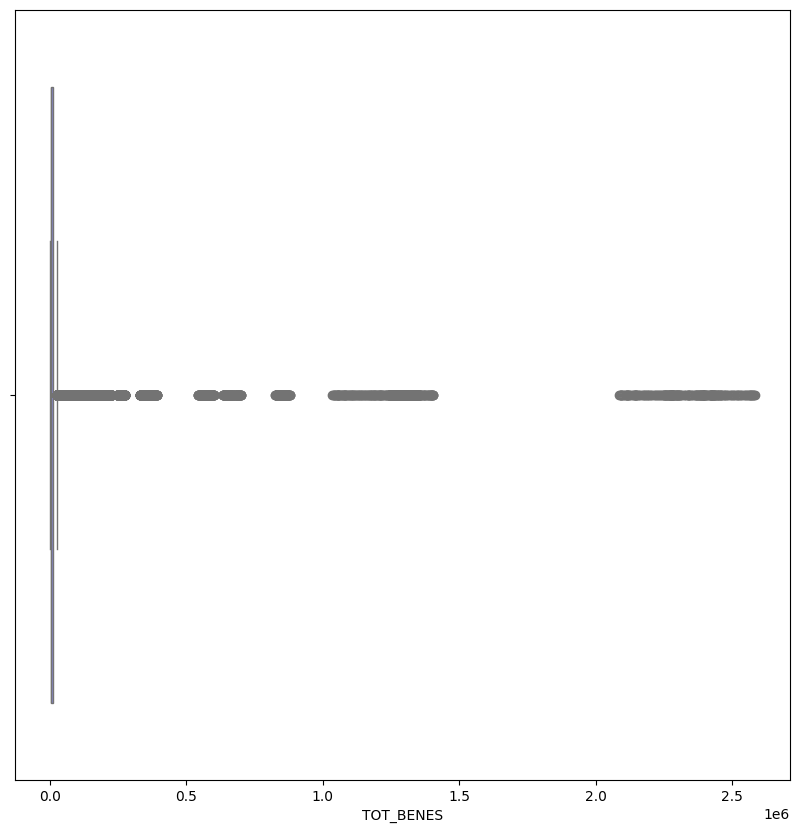

In [19]:
plt.figure(figsize = (10,10))
sns.boxplot(df4, x = 'TOT_BENES', palette = 'cool')
plt.show()

It looks a little odd, but it makes sense. The IQR almost always falls around 0, and there are hundreds of outlier points. This is a bit expected, as this data is organized by state and county. Some counties are much larger than the majority, and therefore can contain a lot of people for that record. However, I still want to check and see if there's anything I can do about skew. Let's check out the top outliers for this column.

In [20]:
outliers = df4[df4['TOT_BENES'] > 2000000]
outliers

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
307457,2020,January,State,IL,Illinois,Total,17,2248597.0,1575662.0,672935.0,...,2054294.0,1381500.0,672794.0,1703755.0,1099684.0,604071.0,396150.0,36716.0,13317.0,1257572.0
308111,2020,January,State,MI,Michigan,Total,26,2085796.0,1099237.0,986559.0,...,1954896.0,968533.0,986363.0,1676107.0,1079000.0,597107.0,332873.0,37152.0,14423.0,1291659.0
308949,2020,January,State,OH,Ohio,Total,39,2365206.0,1280384.0,1084822.0,...,2193182.0,1108615.0,1084567.0,1896335.0,1027008.0,869327.0,392106.0,38846.0,16896.0,1448487.0
310793,2020,February,State,IL,Illinois,Total,17,2251249.0,1577119.0,674130.0,...,2055941.0,1381839.0,674102.0,1705643.0,1099985.0,605658.0,398677.0,36536.0,13186.0,1257244.0
311447,2020,February,State,MI,Michigan,Total,26,2088087.0,1099659.0,988428.0,...,1956687.0,968301.0,988386.0,1677090.0,1077490.0,599600.0,335038.0,36895.0,14290.0,1290867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548351,2025,September,State,MI,Michigan,Total,26,2295554.0,848977.0,1446577.0,...,2160140.0,713770.0,1446370.0,1961465.0,810795.0,1150670.0,373009.0,39005.0,0.0,1549451.0
549189,2025,September,State,OH,Ohio,Total,39,2580882.0,1111808.0,1469074.0,...,2406350.0,937911.0,1468439.0,2191591.0,915345.0,1276246.0,426808.0,42261.0,0.0,1722522.0
551034,2025,October,State,IL,Illinois,Total,17,2458210.0,1382454.0,1075756.0,...,2253131.0,1177777.0,1075354.0,2024136.0,1004466.0,1019670.0,457139.0,32285.0,0.0,1534712.0
551688,2025,October,State,MI,Michigan,Total,26,2297673.0,849798.0,1447875.0,...,2162429.0,714762.0,1447667.0,1963983.0,812005.0,1151978.0,374076.0,39150.0,0.0,1550757.0


If you look in 'BENE_COUNTY_DESC', you'll see that the word 'Total' comes up a lot. Since it's in place of a county. I suspect that it's the total sum of the total beneficiaries for a given year or a given month. Let's test.

In [21]:
test = df4[(df4['BENE_COUNTY_DESC'] == 'Total') &
           (df4['MONTH'] == 'January') &
           (df4['BENE_STATE_DESC'] == 'Ohio')
           ]
test

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
308949,2020,January,State,OH,Ohio,Total,39,2365206.0,1280384.0,1084822.0,...,2193182.0,1108615.0,1084567.0,1896335.0,1027008.0,869327.0,392106.0,38846.0,16896.0,1448487.0
352317,2021,January,State,OH,Ohio,Total,39,2393484.0,1229287.0,1164197.0,...,2225189.0,1061059.0,1164130.0,1940778.0,992058.0,948720.0,393671.0,38368.0,14772.0,1493967.0
395687,2022,January,State,OH,Ohio,Total,39,2426207.0,1174305.0,1251902.0,...,2258441.0,1006592.0,1251849.0,1986477.0,957438.0,1029039.0,411981.0,36287.0,13000.0,1525209.0
439068,2023,January,State,OH,Ohio,Total,39,2468724.0,1140553.0,1328171.0,...,2294680.0,967675.0,1327005.0,2037604.0,893417.0,1144187.0,432104.0,34826.0,13401.0,1557273.0
482449,2024,January,State,OH,Ohio,Total,39,2517290.0,1117024.0,1400266.0,...,2336368.0,937862.0,1398506.0,2117475.0,903608.0,1213867.0,442730.0,46735.0,0.0,1628010.0
522493,2025,January,State,OH,Ohio,Total,39,2563478.0,1109132.0,1454346.0,...,2381798.0,928092.0,1453706.0,2171422.0,908008.0,1263414.0,421320.0,43963.0,0.0,1706139.0


Based on these filters, it looks like 'Total' indicates the sum total of beneficiaries for a specified year, month and county. To test it let's see if I can recalculatue the value for the sum of Ohio in Januaury of 2020. Looking at the TOT_BENES column in the table above, it looks like we are trying to get 2365206.0 as the result.

In [22]:
test2 = df4[(df4['BENE_COUNTY_DESC'] != 'Total') &
            (df4['MONTH'] == 'January') &
            (df4['YEAR'] == 2020) &
            (df4['BENE_STATE_DESC'] == 'Ohio')
            ]

print(test2['TOT_BENES'].sum())

2365206.0


It's a perfect match. This means that any rows with the 'Total' value must be dropped for the same reason we dropped all rows using 'Year' as the 'MONTH'. Again, I can always create the calculation myself later.

In [23]:
df5 = df4[df4['BENE_COUNTY_DESC'] != 'Total']

Now, let's check out that boxplot again.

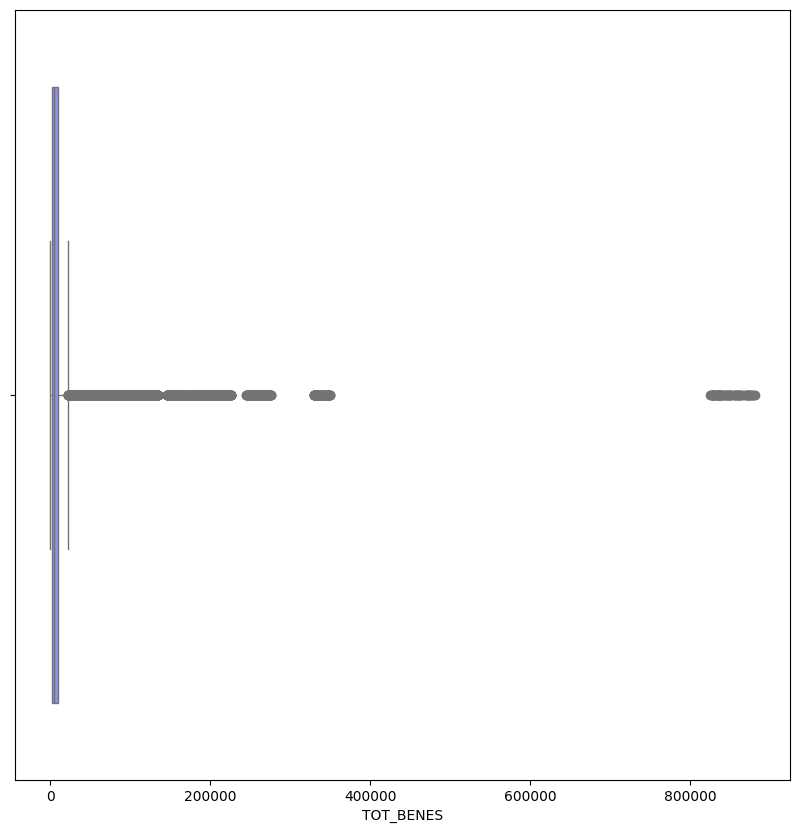

In [24]:
plt.figure(figsize = (10,10))
sns.boxplot(df5, x = 'TOT_BENES', palette = 'cool')
plt.show()

A little better, but still skewed. Let's see if there's anything else that may be extra calculations or erroneus data.

In [25]:
outliers = df5[df5['TOT_BENES'] > 600000]
outliers

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
307473,2020,January,County,IL,Illinois,Cook County,17031,824956.0,560100.0,264856.0,...,735963.0,471165.0,264798.0,629051.0,386232.0,242819.0,191685.0,17684.0,5491.0,414191.0
310809,2020,February,County,IL,Illinois,Cook County,17031,826040.0,561386.0,264654.0,...,736531.0,471895.0,264636.0,629664.0,386940.0,242724.0,193023.0,17601.0,5445.0,413595.0
314145,2020,March,County,IL,Illinois,Cook County,17031,827484.0,561826.0,265658.0,...,737146.0,471506.0,265640.0,630403.0,386602.0,243801.0,194519.0,17551.0,5388.0,412945.0
317481,2020,April,County,IL,Illinois,Cook County,17031,828438.0,561866.0,266572.0,...,737343.0,470789.0,266554.0,631181.0,386367.0,244814.0,195709.0,17356.0,4812.0,413304.0
320817,2020,May,County,IL,Illinois,Cook County,17031,828189.0,561159.0,267030.0,...,736716.0,469704.0,267012.0,630698.0,385302.0,245396.0,195974.0,17177.0,4759.0,412788.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537702,2025,June,County,IL,Illinois,Cook County,17031,875715.0,484730.0,390985.0,...,783891.0,393104.0,390787.0,716380.0,344001.0,372379.0,211143.0,15195.0,0.0,490042.0
541039,2025,July,County,IL,Illinois,Cook County,17031,876906.0,484266.0,392640.0,...,785592.0,393151.0,392441.0,718718.0,344676.0,374042.0,212697.0,15114.0,0.0,490907.0
544376,2025,August,County,IL,Illinois,Cook County,17031,878116.0,485047.0,393069.0,...,786835.0,393967.0,392868.0,720358.0,345855.0,374503.0,214070.0,15021.0,0.0,491267.0
547713,2025,September,County,IL,Illinois,Cook County,17031,879277.0,485614.0,393663.0,...,788303.0,394839.0,393464.0,722108.0,347018.0,375090.0,215254.0,15028.0,0.0,491826.0


Well, hello there Cook County. Let's check and see what counties appeared in this subsection exactly.

In [26]:
outliers['BENE_COUNTY_DESC'].unique()

array(['Cook County'], dtype=object)

I went and checked the US census Bureau website at this link:



It turns out that Cook County is the most populous county in Illinois, so it makes sense that it would have a high number. That means these are probably valid data points, and since the company has not told me to remove any specific counties, these should be left in. Let's lower the number and see if other 'outliers' follow the same pattern.

In [27]:
outliers = df5[df5['TOT_BENES'] > 200000]
outliers['BENE_COUNTY_DESC'].unique()

array(['Cook County', 'Oakland County', 'Wayne County',
       'St. Louis County', 'Cuyahoga County', 'Hennepin County',
       'Franklin County'], dtype=object)

I checked the US Census bureau, and again, these counties are incredibly populated. Each one has a million people minimum, making them valid data points for the same reason as Cook County. St. Louis County is a bit odd because it has 2 entries on the website, one with 200,000 and one with 1,000,000, but St. Louis TOT_BENES are closer to 200,000 so the data checks out.

Just to dot my I's and cross my T's, I'll create a for loop that shows me the counties for the top 1% of entires each numeric column. Then I can go through each county that appears and check how populous it is.

In [28]:
numcols = df5.select_dtypes(include = 'float64')
top_counties = set()

for col in numcols:
    threshold = df5[col].quantile(0.99)
    top_10 = df5[df5[col] >= threshold]

    counties = top_10['BENE_COUNTY_DESC'].unique()
    top_counties.update(counties)

for i in top_counties:
  print(i)

Chippewa County
Dane County
Will County
Hennepin County
Kent County
Pennington County
Lake County
Cook County
Macomb County
Summit County
Montgomery County
Kane County
Rolette County
Dupage County
Allen County
Beltrami County
Jackson County
Oakland County
Hamilton County
Cuyahoga County
Marion County
Ramsey County
Oglala Lakota County
St. Louis County
Sedgwick County
Milwaukee County
Lucas County
Genesee County
Johnson County
Franklin County
Brown County
St. Louis City
Wayne County


From what I can see, the counties presented here are all very populous, and if they aren't, then there TOT_BENES doesn't exceed the actual population. Some of them are a bit less populous than I'd like, but there might be demographic differences, so I'll leave them be. I will actually keep this list for later, as the demographic information could prove useful. I think we're good on the outliers, So I'll check for any **true** duplicates. If a row is completely identical to another row, it's usually erroneus.

In [29]:
df5.duplicated().sum()

np.int64(0)

There are no true duplicates. Yay! At this point, missing data, outliers and duplicate data have all been checked and accounted for. The last thing to do is a final check, and then import the data into a csv file to be loaded into SQL. I'll be changing all null values into '\\N' because that's how SQL interprets nulls.

In [30]:
master_df = df5

In [31]:
master_df.head()

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
307458,2020,January,County,IL,Illinois,Adams County,17001,15002.0,12274.0,2728.0,...,14087.0,11359.0,2728.0,11718.0,9126.0,2592.0,2399.0,181.0,109.0,9029.0
307459,2020,January,County,IL,Illinois,Alexander County,17003,1623.0,1410.0,213.0,...,1527.0,1314.0,213.0,1188.0,1002.0,186.0,489.0,45.0,14.0,640.0
307460,2020,January,County,IL,Illinois,Bond County,17005,3611.0,2756.0,855.0,...,3438.0,2583.0,855.0,2854.0,2071.0,783.0,583.0,50.0,21.0,2200.0
307461,2020,January,County,IL,Illinois,Boone County,17007,9871.0,6455.0,3416.0,...,9150.0,5735.0,3415.0,7586.0,4863.0,2723.0,1266.0,124.0,65.0,6131.0
307462,2020,January,County,IL,Illinois,Brown County,17009,1073.0,839.0,234.0,...,1015.0,781.0,234.0,827.0,603.0,224.0,206.0,NaN,NaN,593.0


In [32]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74690 entries, 307458 to 553631
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   YEAR                                          74690 non-null  int64  
 1   MONTH                                         74690 non-null  object 
 2   BENE_GEO_LVL                                  74690 non-null  object 
 3   BENE_STATE_ABRVTN                             74690 non-null  object 
 4   BENE_STATE_DESC                               74690 non-null  object 
 5   BENE_COUNTY_DESC                              74690 non-null  object 
 6   BENE_FIPS_CD                                  74690 non-null  object 
 7   TOT_BENES                                     73850 non-null  float64
 8   ORGNL_MDCR_BENES                              73231 non-null  float64
 9   MA_AND_OTH_BENES                              73231 non-null

In [33]:
master_df.columns

Index(['YEAR', 'MONTH', 'BENE_GEO_LVL', 'BENE_STATE_ABRVTN', 'BENE_STATE_DESC',
       'BENE_COUNTY_DESC', 'BENE_FIPS_CD', 'TOT_BENES', 'ORGNL_MDCR_BENES',
       'MA_AND_OTH_BENES', 'AGED_TOT_BENES', 'AGED_ESRD_BENES',
       'AGED_NO_ESRD_BENES', 'DSBLD_TOT_BENES',
       'DSBLD_ESRD_AND_ESRD_ONLY_BENES', 'DSBLD_NO_ESRD_BENES',
       'MALE_TOT_BENES', 'FEMALE_TOT_BENES', 'WHITE_TOT_BENES',
       'BLACK_TOT_BENES', 'API_TOT_BENES', 'HSPNC_TOT_BENES',
       'NATIND_TOT_BENES', 'OTHR_TOT_BENES', 'AGE_LT_25_BENES',
       'AGE_25_TO_44_BENES', 'AGE_45_TO_64_BENES', 'AGE_65_TO_69_BENES',
       'AGE_70_TO_74_BENES', 'AGE_75_TO_79_BENES', 'AGE_80_TO_84_BENES',
       'AGE_85_TO_89_BENES', 'AGE_90_TO_94_BENES', 'AGE_GT_94_BENES',
       'DUAL_TOT_BENES', 'FULL_DUAL_TOT_BENES', 'PART_DUAL_TOT_BENES',
       'NODUAL_TOT_BENES', 'QMB_ONLY_BENES', 'QMB_PLUS_BENES',
       'SLMB_ONLY_BENES', 'SLMB_PLUS_BENES', 'QDWI_QI_BENES',
       'OTHR_FULL_DUAL_MDCD_BENES', 'A_B_TOT_BENES', 'A_B_ORGNL_MD

In [34]:
master_df.to_csv('beneficiaries.csv', index = False, na_rep='\\N')

The data preprocessing is complete. Please see the specified SQL files in the READ ME section of this project on GitHub to continue viewing the project.

In [41]:
master_df[['TOT_BENES', 'ORGNL_MDCR_BENES', 'MA_AND_OTH_BENES', 'A_B_MA_AND_OTH_BENES']]

,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,A_B_MA_AND_OTH_BENES
307458,15002.0,12274.0,2728.0,2728.0
307459,1623.0,1410.0,213.0,213.0
307460,3611.0,2756.0,855.0,855.0
307461,9871.0,6455.0,3416.0,3415.0
307462,1073.0,839.0,234.0,234.0
...,...,...,...,...
553627,15465.0,4480.0,10985.0,10980.0
553628,7479.0,2346.0,5133.0,5133.0
553629,37642.0,10824.0,26818.0,26814.0
553630,20820.0,7036.0,13784.0,13779.0
